In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)


# Load test data
X_test = pd.read_csv(Path(r"data/X_test_selected.csv"))
y_test = pd.read_csv(Path(r"data/y_test.csv")).squeeze("columns")

# Load trained models
logreg_model = joblib.load(Path(r"models/logreg_model.joblib"))
rf_model = joblib.load(Path(r"models/rf_model.joblib"))
xgb_model = joblib.load(Path(r"models/xgb_model.joblib"))
cat_boost = joblib.load(Path(r"models/cat_boost.joblib"))

models = {
    "Logistic Regression": logreg_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "CatBoost": cat_boost,
}

print("Data and models loaded.")

Data and models loaded.


## Predictions com os 3 modelos

In [17]:
results = []
predictions_dict = {}

for model_name, model in models.items():
    #print current model being evaluated
    print(f"Evaluating {model_name}...")
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    predictions_dict[model_name] = {
        "y_pred": y_pred,
        "y_prob": y_prob
    }

    results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False)
display(results_df)

Evaluating Logistic Regression...
Evaluating Random Forest...
Evaluating XGBoost...
Evaluating CatBoost...


,model,accuracy,precision,recall,f1,roc_auc
2,XGBoost,0.730289,0.257293,0.691871,0.375096,0.781986
3,CatBoost,0.736813,0.260681,0.680529,0.376963,0.777593
1,Random Forest,0.743780,0.265724,0.674858,0.381308,0.769818
0,Logistic Regression,0.621143,0.197496,0.730624,0.310941,0.745657


In [18]:
for threshold in [0.5, 0.6, 0.7, 0.8, 0.9]:
    print(f"\nThreshold = {threshold}")
    
    results = []

    for model_name, model in models.items():
        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)

        results.append({
            "model": model_name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred),
            "roc_auc": roc_auc_score(y_test, y_prob)
        })

    display(pd.DataFrame(results).sort_values("roc_auc", ascending=False))


Threshold = 0.5


,model,accuracy,precision,recall,f1,roc_auc
2,XGBoost,0.730289,0.257293,0.691871,0.375096,0.781986
3,CatBoost,0.736813,0.260681,0.680529,0.376963,0.777593
1,Random Forest,0.741900,0.264228,0.675803,0.379915,0.769818
0,Logistic Regression,0.621143,0.197496,0.730624,0.310941,0.745657



Threshold = 0.6


,model,accuracy,precision,recall,f1,roc_auc
2,XGBoost,0.761915,0.281262,0.665406,0.395395,0.781986
3,CatBoost,0.772974,0.288747,0.642722,0.398476,0.777593
1,Random Forest,0.783479,0.296196,0.618147,0.400490,0.769818
0,Logistic Regression,0.700210,0.229814,0.664461,0.341511,0.745657



Threshold = 0.7


,model,accuracy,precision,recall,f1,roc_auc
2,XGBoost,0.790556,0.307018,0.628544,0.412531,0.781986
3,CatBoost,0.800177,0.315426,0.604915,0.414642,0.777593
1,Random Forest,0.817649,0.335192,0.568053,0.421606,0.769818
0,Logistic Regression,0.763795,0.264834,0.573724,0.362388,0.745657



Threshold = 0.8


,model,accuracy,precision,recall,f1,roc_auc
2,XGBoost,0.817096,0.338919,0.592628,0.431224,0.781986
3,CatBoost,0.823731,0.345622,0.567108,0.429492,0.777593
1,Random Forest,0.848059,0.385007,0.500000,0.435033,0.769818
0,Logistic Regression,0.816543,0.319520,0.502836,0.390746,0.745657



Threshold = 0.9


,model,accuracy,precision,recall,f1,roc_auc
2,XGBoost,0.845516,0.387375,0.551040,0.454936,0.781986
3,CatBoost,0.851487,0.394834,0.505671,0.443431,0.777593
1,Random Forest,0.873604,0.453245,0.389414,0.418912,0.769818
0,Logistic Regression,0.859118,0.401280,0.414934,0.407993,0.745657


## Classification reports e confusion matrixes finais


Logistic Regression


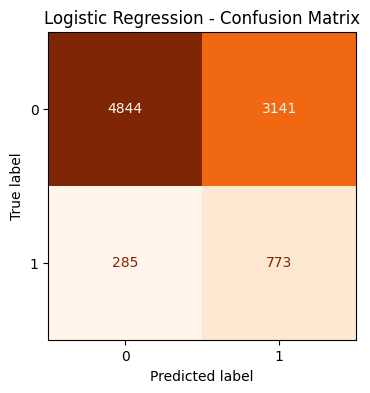


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.61      0.74      7985
           1       0.20      0.73      0.31      1058

    accuracy                           0.62      9043
   macro avg       0.57      0.67      0.52      9043
weighted avg       0.86      0.62      0.69      9043


Random Forest


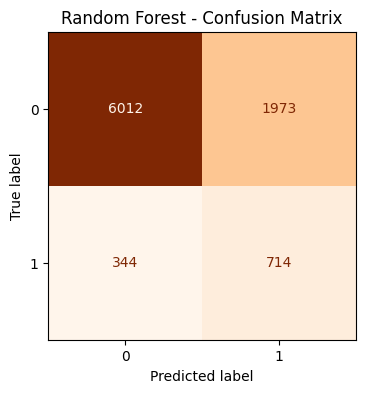


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.75      0.84      7985
           1       0.27      0.67      0.38      1058

    accuracy                           0.74      9043
   macro avg       0.61      0.71      0.61      9043
weighted avg       0.87      0.74      0.78      9043


XGBoost


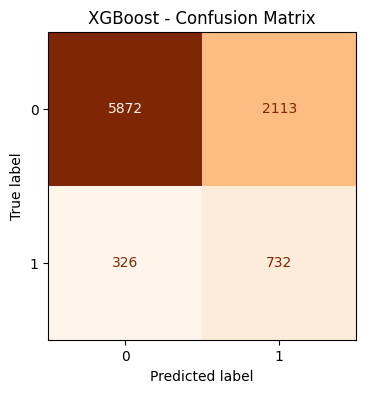


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.74      0.83      7985
           1       0.26      0.69      0.38      1058

    accuracy                           0.73      9043
   macro avg       0.60      0.71      0.60      9043
weighted avg       0.87      0.73      0.78      9043


CatBoost


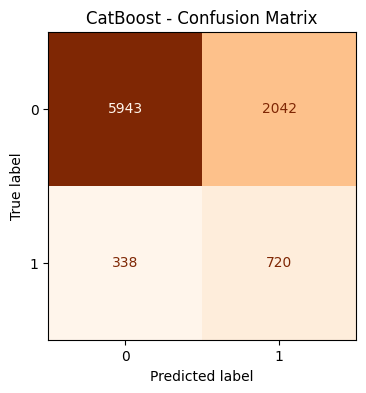


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.74      0.83      7985
           1       0.26      0.68      0.38      1058

    accuracy                           0.74      9043
   macro avg       0.60      0.71      0.61      9043
weighted avg       0.87      0.74      0.78      9043



In [ ]:
for model_name, preds in predictions_dict.items():
    print(f"\n{'='*60}")
    print(model_name)
    print(f"{'='*60}")

    # Confusion matrix
    cm = confusion_matrix(y_test, preds["y_pred"])

    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    disp.plot(
        ax=ax,
        cmap="Oranges",
        colorbar=False,
        values_format="d"
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_test, preds["y_pred"]))

## ROC Curve

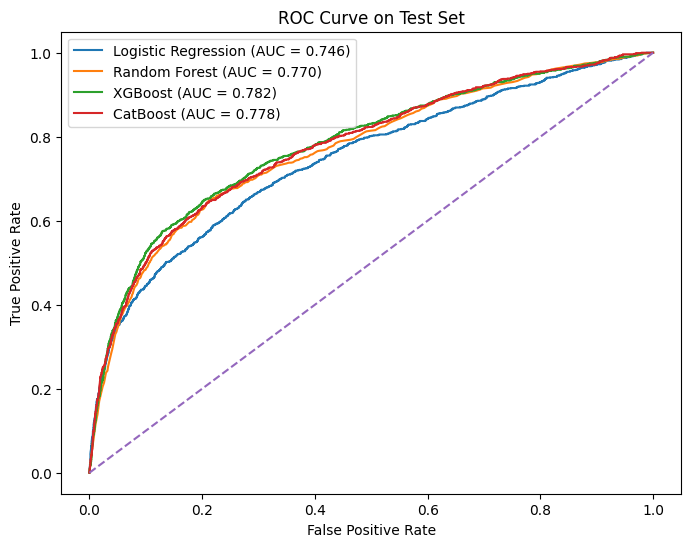

In [ ]:
plt.figure(figsize=(8, 6))

for model_name, preds in predictions_dict.items():
    fpr, tpr, _ = roc_curve(y_test, preds["y_prob"])
    auc_score = roc_auc_score(y_test, preds["y_prob"])
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set")
plt.legend()
plt.show()

## Final feature importances para Random Forest e XGboost

In [ ]:
feature_names = X_test.columns

# Random Forest feature importance
rf_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("Random Forest - Top 15 Feature Importances")
display(rf_importance.head(15))

# XGBoost feature importance
xgb_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("XGBoost - Top 15 Feature Importances")
display(xgb_importance.head(15))

# CatBoost feature importance
cat_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": cat_boost.feature_importances_
}).sort_values("importance", ascending=False)

print("CatBoost - Top 15 Feature Importances")
display(cat_importance.head(15))

Random Forest - Top 15 Feature Importances


,feature,importance
1,balance,0.157101
0,age,0.136538
2,day,0.120944
3,campaign,0.069436
21,housing_yes,0.068791
4,pdays,0.051979
31,month_may,0.048776
5,previous,0.046289
36,poutcome_success,0.031233
16,marital_married,0.025688


XGBoost - Top 15 Feature Importances


,feature,importance
36,poutcome_success,0.270068
5,previous,0.087845
21,housing_yes,0.080555
33,month_oct,0.050623
30,month_mar,0.041371
31,month_may,0.035886
24,month_aug,0.030382
34,month_sep,0.027517
26,month_feb,0.027275
16,marital_married,0.025321


CatBoost - Top 15 Feature Importances


,feature,importance
2,day,11.374294
0,age,11.349567
21,housing_yes,9.864485
36,poutcome_success,9.696637
1,balance,7.813567
4,pdays,6.702742
3,campaign,5.225737
31,month_may,4.836590
5,previous,4.755994
24,month_aug,3.004759


## Final feature importances para logistic regression

In [ ]:
logreg_importance = pd.DataFrame({
    "feature": X_test.columns,
    "coefficient": logreg_model.coef_[0],
    "abs_coefficient": np.abs(logreg_model.coef_[0])
}).sort_values("abs_coefficient", ascending=False)

print("Logistic Regression - Top 15 Coefficients by Absolute Value")
display(logreg_importance.head(15))

Logistic Regression - Top 15 Coefficients by Absolute Value


,feature,coefficient,abs_coefficient
1,balance,7.541380,7.541380
3,campaign,-4.646776,4.646776
5,previous,4.563895,4.563895
36,poutcome_success,4.433240,4.433240
33,month_oct,3.056068,3.056068
30,month_mar,2.695741,2.695741
34,month_sep,2.419130,2.419130
31,month_may,-2.002536,2.002536
25,month_dec,1.964014,1.964014
24,month_aug,-1.886760,1.886760


## SHAP analysis

Esta análise ajuda a perceber as decisões do modelo e os features que contribuem mais e de que forma para ser positivo ou negativo

### SHAP para Logistic Regression

In [ ]:
! uv pip install shap

Checked 1 package in 18ms


c:\Users\gvinicir\OneDrive - NTT DATA EMEAL\Documents\GitHub\hackaton-NTT\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


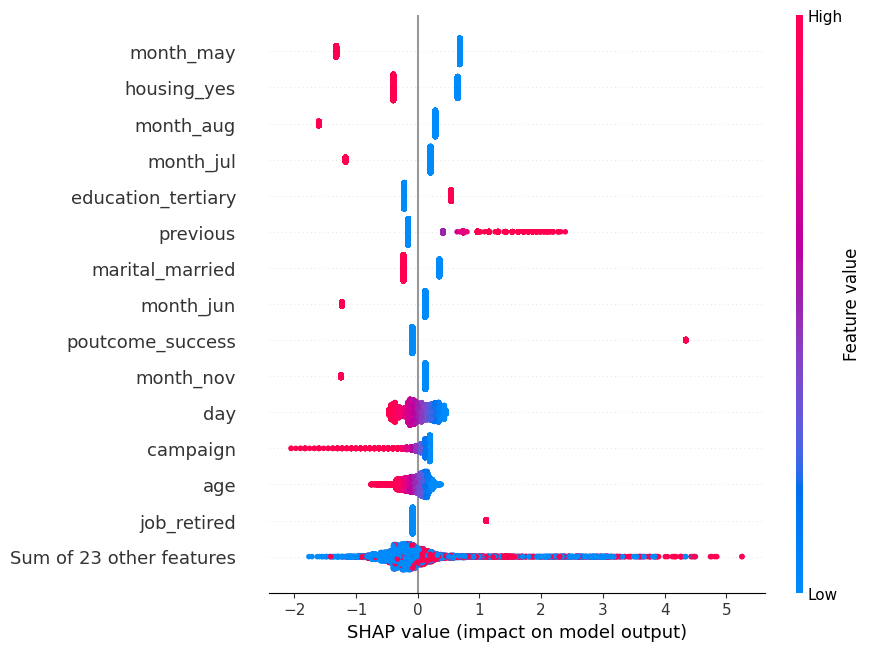

In [ ]:
import shap

explainer_logreg = shap.Explainer(logreg_model, X_test)
shap_values_logreg = explainer_logreg(X_test)

shap.plots.beeswarm(shap_values_logreg, max_display=15)

### SHAP para Random Forest

In [ ]:
explainer_rf = shap.TreeExplainer(rf_model)
shap_values_rf = explainer_rf.shap_values(X_test)

# For binary classification, use class 1 if shap returns a list
if isinstance(shap_values_rf, list):
    shap.summary_plot(shap_values_rf[1], X_test, max_display=15)
else:
    shap.summary_plot(shap_values_rf, X_test, max_display=15)

### SHAP para XGBoost

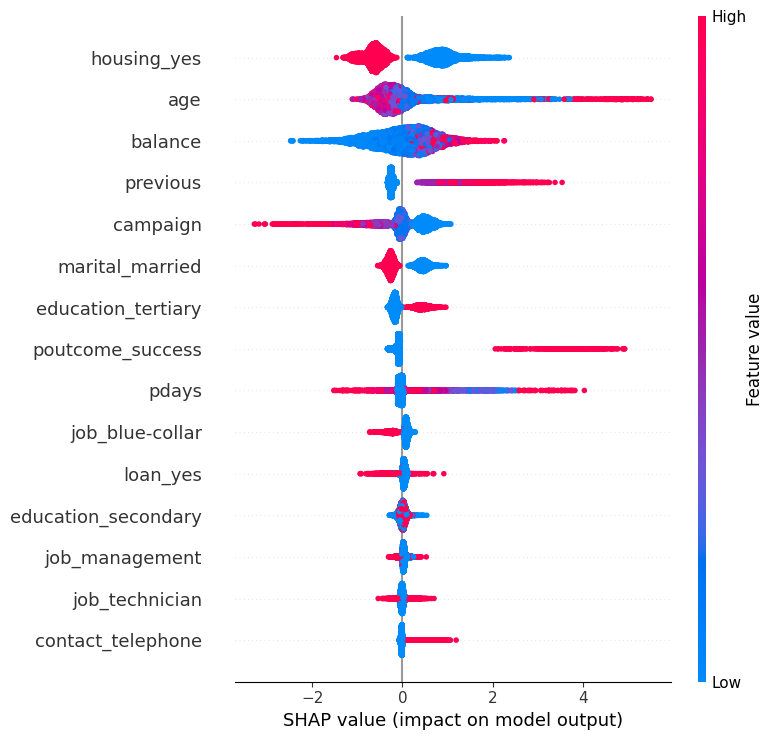

In [ ]:
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_test)

shap.summary_plot(shap_values_xgb, X_test, max_display=15)

### SHAP para CatBoost

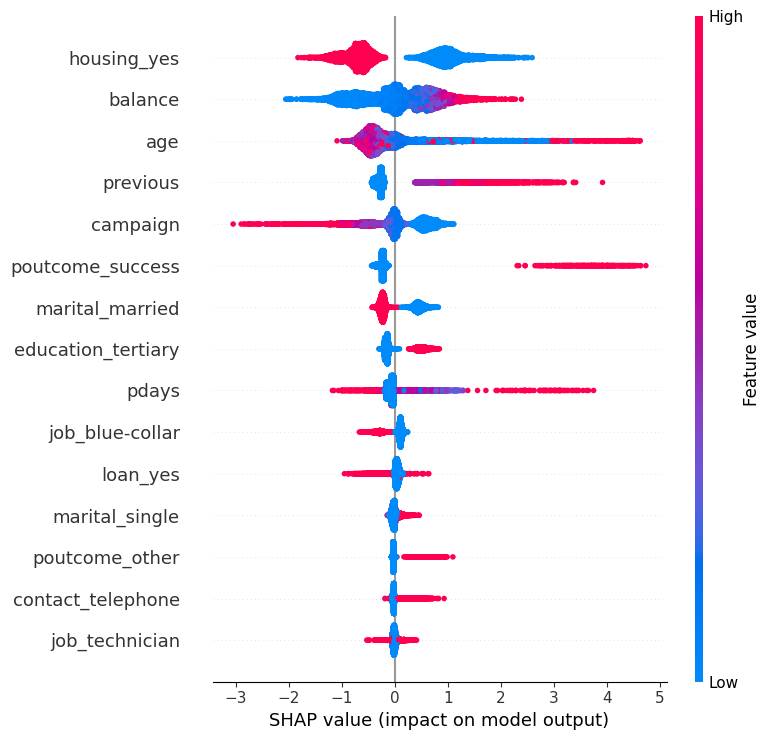

In [ ]:
explainer_cat = shap.TreeExplainer(cat_boost)
shap_values_cat = explainer_cat.shap_values(X_test)

shap.summary_plot(shap_values_cat, X_test, max_display=15)

## Guardar final predictions

In [ ]:
predictions_df = X_test.copy()
predictions_df["y_true"] = y_test.values

for model_name, preds in predictions_dict.items():
    safe_name = model_name.lower().replace(" ", "_")
    predictions_df[f"{safe_name}_pred"] = preds["y_pred"]
    predictions_df[f"{safe_name}_prob"] = preds["y_prob"]

predictions_df.to_csv(Path(r"data/test_set_predictions.csv"), index=False)

print("Predictions saved to data/test_set_predictions.csv")
display(predictions_df.head())

Predictions saved to data/test_set_predictions.csv


,age,balance,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,...,poutcome_success,y_true,logistic_regression_pred,logistic_regression_prob,random_forest_pred,random_forest_prob,xgboost_pred,xgboost_prob,catboost_pred,catboost_prob
0,0.285714,0.078614,0.016129,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0,0,0.104612,0,0.060000,0,0.075430,0,0.076781
1,0.337662,0.076235,0.016129,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0,0.208074,0,0.003333,0,0.101849,0,0.097444
2,0.168831,0.076035,0.064516,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0,0.157358,0,0.033333,0,0.069970,0,0.082722
3,0.233766,0.078750,0.048387,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0,0,0.121326,0,0.056667,0,0.118464,0,0.090510
4,0.207792,0.090244,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0,0,0.450261,0,0.483333,0,0.334346,0,0.383467
